# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 4</span>

### Exercise 04.1

The Molecular Dynamics (MD) code starts the simulation run from a provided spatial configuration of the $N$ particles (file: <font face="Courier">config.0</font>) and, once the simulation is finished, it writes out the final configuration (file: <font face="Courier">config.final</font>).



1. <span style="color:red">Improve the MD code by enabling (you should insert this option via a boolean-like variable in the input file) the **possibility** to **(re)start** reading not only a **actual** spatial configuration [$\vec{r}(t)$] file but also an **old** spatial configuration [$\vec{r}(t-dt)$] file</span> (files: <font face="Courier" color="red">old.0</font> and <font face="Courier" color="red">old.final</font>).  
2. <span style="color:red">Moreover, add the possibility to rescale the velocities [i.e. to correct $\vec{r}(t-dt)$] in order to match a desired temperature</span>.


The typical required operations when the re-start option will be enabled are:


1. read $\vec{r}(t)$ and $\vec{r}(t-dt)$ from the corresponding input files
2. compute $\vec{r}(t+dt)$ with one step of the Verlet algorithm; with $\vec{r}(t+dt)$ and $\vec{r}(t)$ compute $\vec{v}(t+dt/2)$; finally obtain the actual temperature $T(t+dt/2)$
3. by comparing $T(t+dt/2)$ with the desired/target temperature  $T^\star$ extract a scaling factor for the velocities and rescale them: $\vec{v}(t) \to \vec{v}_s(t)$
4. use $\vec{v}_s(t)$ to estimate a novel **old** spatial configuration: $\vec{r}_{new}(t) = \vec{r}(t+dt) - dt \vec{v}_s$
5. use $\vec{r}_{new}(t)$ and $\vec{r}(t+dt)$ to start the simulation
6. Do not forget to use **periodic boundary contitions** every time is appropriate!

This will help you, especially in the equilibration phases of your simulations.

## Molecular Dynamics (MD) Simulations ##
---------------
- Molecular dynamics simulations serve as computational tools for investigating the behavior of physical systems at the atomic level.
- The end goals could be:
  
  - To predict new materials properties
  - To design new drugs
  - To study protein foldings<br><br>
    
- Computer experiments vs. real experiments<br>

<div style="margin-left: 30px">
It is important to note that computer simulations cannot substitute real experiments. In fact, a simulated system is by definition based on arbitrary pre-chosen rules. Therefore, it would be circular logic to infer any conclusions from it (like establishing new physical laws).
<br><br>
    
However, simulations can bring extremely valuable insight to complement the scientific method. Examples of this include:
- Helping designing new experiments, saving time and money.
- Predict/ rule out experiments outcomes
- Geting additional insight when it is difficult to study a system directly (e.g. in extreme conditions)
- Backing up real data
- Provide an approximate numerical solution when computing an exact anlytical solution is impossible
</div>

## MD Steps ##
------

The typical workflow of a MD simulation is the following:

1. Create an initial state (nb. of particles, boundary conditions, etc.)
2. Introduce interaction potentials (e.g. Lennard-Jones), compute forces
3. Predict how particles move (e.g. with the Verlet algorithm), compute new positions
4. Fix the system's conditions:<br><br>
   - Set constant temperature $T$, or constant energy, etc.
   - If necessary, re-adjust how the particles move (equilibration)<br><br>
5. Measure the other system's quantities, like $\langle  U \rangle$ or $\langle  K \rangle$: <br><br>
   <div style="margin-left: 30px">
   $\Rightarrow$ This is in fact the objective of the MD simulation: to measure how the system behaves under certain controlled conditions.
   </div>

## Some Theory on Thermodynamics / Statistical Mechanics ##
----------
 - Thermodynamics/ Statistical Mechanics: measuring macroscopic quantities with average microscopic quantities.
 - We make the distinction between microstates and macrostates
 - We cannot determine the initial microstate of a system based on its macrostate: impossible to determine the precise time evolution of a system based on its macrostate.

### • Ensemble  Theory ###

Gibbs ensemble theory: many different microstates lead to the same macrostate. It is thereforre not necessary to know precisely the configuration of each particle of the system to determine its macroscopic quanities.

### • Time Average vs. Initial Conditions ###

- It can be proven (slide 9 lect.4) that for a sufficient long time interval, the average (averaged over time) microscopic configurations $< f >$ do not depend on the initial conditions $(q_0, p_0)$.
- Also, it can also be shown that the average over many initial conditions is equivalent to the time average of a microscopic configuration. In other words:

$$
<f> = \langle < f> \rangle _{init} 
$$

### • Ergodic Hypothesis ###

- The ensemble averages at equilibrium do not depend on time
- Ergodic Hypothesis:

$$
<f>_{\rho(q_0,p_0)} = \lim_{N_{init} \to \infty} \langle < f> \rangle _{init} = \lim_{\Delta t \to \infty} <f>
$$

<u>Nota Bene</u>: this is not always the case, rather, this reflects a particularly ideal case.

## Molecular Dynamics Simulation (Edited) ##
----------------

The purpose of a Molecular Dynamics (MD) simulation is to simulate a system of time-dependent particles subject to an interaction potential. By integrating the equations of motions of the particles, and given appropriate boundary conditions, we can determine their positions and velocities at all times.

Based on these microscopic quantities one can then determine the macroscopic quantities of the system such as temperature, pressure, heat capacity, etc. using statistical mechanics.

To accurately and efficiently integrate the equations of motions, we need an algorithm that has the following properties:

- The algorithm should conserve energy and momentum and be reversible: when $\delta t \rightarrow -\delta t$ the system should go back to its original state.
- Computationally efficient
- Should permit long time step for integration
- Only one force evaluation per time step (important for complex potential)

### • The Verlet Algorithm (Edited) ###

<div style="margin-left: 30px">
We know well how to integrate the equations of motion of classical mechanics (at least those solvable analytically). The first main obstacle we might encounter when translating this into a numerical model, is that while the equations of motions we humans are able to solve with pen and paper live in a continuous world, a <b>computer</b> can only integrate these equations in <b>discrete steps</b>. <br><br>

Therefore we need an algorithm that integrates the equations of motions discretly. A widely used "finite-difference" method to this end is the <b>Verlet's</b> algorithm (named after Loup Verlet who introduced it in 1967 to specifically solve an MD simulation with the limited computational power of the era). Other than accurately solving the equations of motions, it has also been proven to be an algorithm that provides <b>good energy stability</b> (meaning that the error on energy doesn't grow exponentially as the simulation proceeds).<br><br>

Mathematically, it is derived from the Taylor expansion:

$$
\begin{align}
\vec{r} (t+\delta t) = \vec{r} + \delta t \vec{v}(t) + \frac{1}{2} \delta t^2 \vec{a}(t) + \frac{1}{3!} \delta t^3 \vec{a}(t) + \mathcal{O}(\delta t^4) \\
\vec{r} (t-\delta t) = \vec{r} - \delta t \vec{v}(t) + \frac{1}{2} \delta t^2 \vec{a}(t) - \frac{1}{3!} \delta t^3 \vec{a}(t) + \mathcal{O}(\delta t^4) \\
\end{align}
$$

Summing the above equations give:

$$
\Rightarrow \vec{r} (t-\delta t) \simeq 2 \vec{r}(t) - \vec{r}(t-\delta t) + \delta t^2 \vec{a}(t)
$$

<br><br>

<u>Note</u>: the position vector $\vec{r}(t+\delta t)$ is calculated from the position vectors at time $t$ and $t-\delta t$ (making the Verlet's algorithm a "two-step" method). This means that the initial positions $\vec{r}(0)$ and initial velocities $\vec{v}(0)$ <b>alone are not sufficient to integrate</b> the equations of motions. <br>

The Verlet's algorithm also doesn't need to compute the velocities to compute new positions. It is usually velocities that are deduced from changes in positions. Finally, the symmetry of the equations make the Verlet's algorithm suitable for time-reversibility.

</div>



### • Limitations / Issues and how to remediate them ###

<div style="margin-left: 30px">
<u>Effect of long simulation time:<br/></u>
<br/>
Like in real-world experiments, one must take into account the error of any results obtained from a computer simulation. In principle, the longer we average the results of the simulation, the more accurate the error is. However, there's a major obstacle that prevents running the simulation for a too long time: the chaotic motion of particles, which can be understood as follows. <br><br>

Consider a particle with two slightly different initial conditions. If we can determine thanks to the equations of motion the two different trajectories the particle might take, the divergence between the two paths grows exponentially with time. This prevents us to keep the error in check if the experiment is run for too long.

To tackle this issue we will take full advantage of the ergodic hypothesis. Under this hypothesis, we can average many microscopic initial states and obtain the average macroscopic quantities of the system independently of time. Furthermore, still under this hypothesis, taking a sequence of many initial individual microstates is equivalent to the time evolution of the system with conserved macroscopic quantities (such as energy).

This feature allow us to fully describe our system and getting an accurate measure of the error (since in this case it is no longer affected by chaotic divergence).

</div>

<div style="margin-left: 30px">
<u>Issue with the description of the interaction potential:<br/></u>
<br/>
Potentials like the Lennard-Jones potential, models "molecular connectivity", describing which atoms are bonded to which. So the simulation can model vibrations, rotations, or conformational changes, but not chemical reactions.
</div>
<br/>
<div style="margin-left: 30px">
<u>Issue with the periodic boundary conditions:<br/></u>
</div>

## Program Workflow ##
----------

### 1.  Initialization ###

- Reading input parameters from ```input.dat``` , namely:
  - temperature
    - number of particles
    - density of particles (rho)
    - cutoff radius (rcut)
    - time step (delta)
    - number of steps nstep
    - restart option
      
- The program reads the initial configuration of the particles $r(t)$ from the provided ```config.0```. At this stage there are two cases.

  - Case ```restart=="true"```. We start a new simulation from scratch, the program needs to compute a "temporary previous step" $r_{temp}(t-dt)$ in order to use the Verlet algorithm and to equilibrate to a target temperature. So in essence the program:

      - Reads the initial configuration of the particles $r(t)$ from the provided ```config.0```.
      - Generates random velocities, removes center-of-mass motion, and rescales them to match the target temperature.
      - Computes a "temporary previous configuration" $r_{temp}(t-dt)$ into ```old.0```
      - The simulation proceeds using the Verlet algorithm
      - At the end of the run:
          - Writes final previous step $r(t-dt)$ into ```old.final```
          - Writes final configuration $r(t)$ into ```config.final```

  - Case ```restart=="false"``` , then the program:
 
      - Reads its current configuration $r(t)$ into ```config.final```and its previous step configuration $r(t-dt)$ into ```old.final```.
      - Proceeds with the verlet algorithm to compute the next configurations.
      - At the end of the run:
          - Writes final previous step $r(t-dt)$ into ```old.final```
          - Writes final configuration $r(t)$ into ```config.final```

### 2. Equilibration ###

## Lennard-Jones Reduced Units ##
-----------

When dealing with simulations it is convenient to work with reduced (dimensionless) units. This is to avoid setting values like $\epsilon$ or $k_b$ and performing calculations with them. In fact, given that their values are often much higher or much lower than 1 we are at risk of encountering over/underflow errors when running our program.

Recall that the Lennard-Jones (LJ) potential is given by:

$$
V(r) = 4\varepsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right]
$$

where:

- \( $\varepsilon $\): depth of the potential well (energy scale) <font color="red"> SET TO $\sigma = 1$ IN MD PROGRAM </font>
- \( $\sigma$ \): finite distance at which the potential is zero (length scale) <font color="red"> SET TO $\sigma = 1$ IN MD PROGRAM </font>
- \( $r $\): inter-particle distance

And so the reduced units used in our simulation are:

- Length: $r*= \frac{r}{\sigma}$
- Energy: $E*= \frac{E}{\varepsilon}$
- Temperature: $T*= \frac{k_B T}{\varepsilon}$

The input values set in the configuration files are all in Lennard-Jones reduced values.

_____

## Temperature Rescaling ##

Why do we need temperature rescaling? When performing our molecular dynamics simulation, we must ensure that it reflects a physically accurate system. In particular, if our simulated system is isolated, total energy must be conserved.

Supposing our system's potential energy is constant. Then kinetic energy must also remain constant (by conservation of total energy). Kinetic energy is proportional to temperature $T$ which in turn depends on the total particles' mean squared velocities $\langle v^2 \rangle$ through the formulas:

- $K = \frac{3}{2} N k_B T$

- $T = \frac{m \langle v^2 \rangle}{k_B}$

If we set the temperature of the system at $T_0$, then temperature rescaling is necessary to ensure that the kinetic energy of the particles corresponds to the desired temperature of the system. This helps maintain the physical accuracy of the simulation, allowing it to reflect realistic thermodynamic behavior.

--------
## How Rescaling Works ##

Let $T_0$ be the target temperature at which we want to set our system. Whereas $T$ is the current temperature depending on the particles velocities.

We can rescale our velocities $v_i$ by a factor $\lambda$ such that:

$$ \lambda = \sqrt{\frac{T_0}{T}} $$

The we update all the velocities as:

$$
v_i' = \lambda v_i
$$

This brings the system to the correct temperature by directly adjusting the kinetic energy.

Specifically, the **equipartition theorem** tells us:

$$
\langle K \rangle = \frac{3}{2} N k_B T
$$

where:

- $ K$ is the total kinetic energy,  
- $N$ is the number of particles,  
- $ k_B $ is Boltzmann's constant (set to 1 in Lennard-Jones units),  
- $ T $ is the temperature.

---

Now, the **kinetic energy per particle** is:

$$
K = \frac{1}{2} m \langle v_x^2 + v_y^2 + v_z^2 \rangle = \frac{3}{2} k_B T
$$

Assuming $m = 1 $ and $ k_B = 1 $, we can solve for the **mean squared velocity**:

$$
\langle v^2 \rangle = v_x^2 + v_y^2 + v_z^2 = 3T
$$

---

So, if the computed average velocity squared is `sumv2`, and we want to **rescale** to get the target temperature $ T $, the correct **scaling factor** $ \lambda $ must satisfy:

$$
\lambda^2 \cdot \text{sumv2} = 3T \quad \Rightarrow \quad \lambda = \sqrt{\frac{3T}{\text{sumv2}}}
$$



-------
## Rescaling Implementation ##

###  1. Initialization (`Input()` function)

When the simulation starts from scratch (`restart == "true"`), random velocities are assigned to particles. These velocities are then **rescaled** to ensure the system starts with the correct temperature (`temp` from `input.dat`).

```cpp
    lambda = sqrt(3 * temp / sumv2);   // lambda = velocity scale factor 
    for (int i=0; i<npart; ++i)
    {
      vx[i] *= lambda;
      vy[i] *= lambda;
      vz[i] *= lambda;
    }
```

This guarantees that the initial kinetic energy (and therefore the temperature) is set correctly.


###  2. Equilibration (`systemEquilibration()` function)

Rescaling is also done periodically during the equilibration phase. This helps guide the system to a steady-state temperature (especially useful if it's not close at the start).

In `systemEquilibration(int N, double T_i, double T_f, int N_resc)`:

```cpp
velocity_rescaling(mean_v2_history);
```

The scale factor `fs` is computed as:

```cpp
lambda = sqrt(3 * temp / mean_squared_velocity);
```

Where:

- `temp` is the target temperature.
- `mean_squared_velocity` is the average of $v_x^2+v_y^2+v_z^2$ over all particles.

Then all particle velocities are multiplied by `fs`:

```cpp
vx[i] *= lambda;
vy[i] *= lambda;
vz[i] *= lambda;
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
output_data = []
colors = ['blue', 'green', 'purple', 'red']
names = [r'$E_{pot}$', r'$E_{kin}$', r'$E_{tot}$', 'T']

output_data.append(np.loadtxt("./MolecularDynamics_NVE/output_epot_4_1.dat"))
output_data.append(np.loadtxt("./MolecularDynamics_NVE/output_ekin_4_1.dat"))
output_data.append(np.loadtxt("./MolecularDynamics_NVE/output_etot_4_1.dat"))
output_data.append(np.loadtxt("./MolecularDynamics_NVE/output_temp_4_1.dat"))

In [3]:
def read_input_dat(filename):
    values = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip().lower()
            if not line:
                continue
            if line in ["true", "false"]:
                values.append(line == "true")
            else:
                try:
                    values.append(float(line))
                except ValueError:
                    continue 

    if len(values) != 7:
        raise ValueError(f"Expected 7 values, found {len(values)} — check file formatting")

    temp, npart, rho, rcut, delta, nstep, restart = values
    return {
        "temp": temp,
        "npart": int(npart),
        "rho": rho,
        "rcut": rcut,
        "delta": delta,
        "nstep": int(nstep),
        "restart": restart,
    }

params = read_input_dat("./MolecularDynamics_NVE/input.dat")
#print(params)

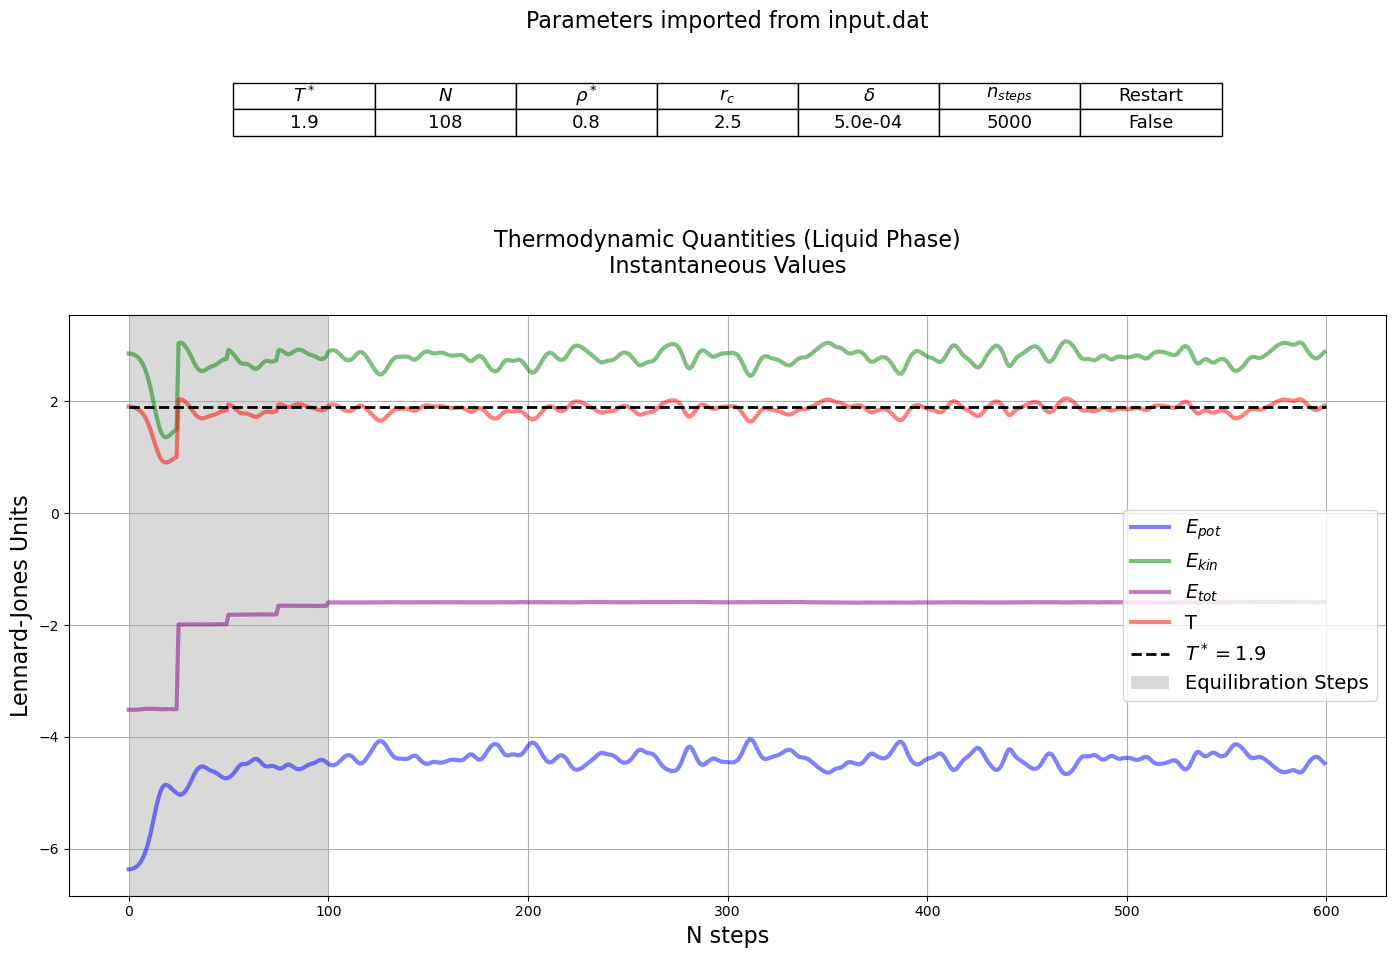

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.18, 0.82], hspace=0.4)

ax_table = fig.add_subplot(gs[0])
ax_table.axis("off")

ax_table.text(
    0.5, 1.1,
    "Parameters imported from input.dat",
    fontsize=16,
    ha="center", va="bottom",
)

param_labels = [r'$T^*$', r'$N$', r'$\rho^*$', r'$r_c$', r'$\delta$', r'$n_{steps}$', 'Restart']
param_values = [
    f"{params['temp']:.3g}",
    int(params['npart']),
    f"{params['rho']:.3g}",
    f"{params['rcut']:.3g}",
    f"{params['delta']:.1e}",
    int(params['nstep']),
    str(params['restart'])
]

table = ax_table.table(
    cellText=[param_values],
    colLabels=param_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(0.75, 1.6)

for key, cell in table.get_celld().items():
    cell.set_height(cell.get_height() * 0.9)

ax = fig.add_subplot(gs[1])
ax.set_title('Thermodynamic Quantities (Liquid Phase)\nInstantaneous Values', fontsize=16, pad=30)
ax.set_xlabel('N steps', fontsize=16)
ax.set_ylabel('Lennard-Jones Units', fontsize=16)

for i in range(4):
    ax.plot(output_data[i], color=colors[i], alpha=0.5, linewidth=3, linestyle='-', label=names[i])

ax.hlines(params["temp"], 0, len(output_data[0]),
          color='black', linewidth=2, linestyle='--', label=rf'$T^* = {params["temp"]}$')
ax.axvspan(0, 100, facecolor='black', alpha=0.15, label='Equilibration Steps')

ax.legend(loc='right', fontsize=14)
ax.grid(True)

plt.subplots_adjust(top=0.93, bottom=0.08, hspace=0.25)
plt.show()

### Exercise 04.2

The Molecular Dynamics code we have provided prints out only instantaneous values for the total (internal) energy per particle, $E/N$, potential energy per particle, $U/N$, kinetic energy per particle, $K/N$, and temperature, $T$.
Take the MD code and include block averaging: 

Divide the <span style="color:blue"><font face="Courier">nstep</font></span> of the simulation into <span style="color:blue"><font face="Courier">nblocks</font></span>. By exploiting these blocks, <span style="color:red">code the calculation of the average values and the uncertainties for $E/N$, $U/N$, $K/N$ and $T$</span>, that will be written in new specific output files, for example: <font face="Courier">ave_epot.out, ave_ekin.out, ave_etot.out, ave_temp.out</font></span>

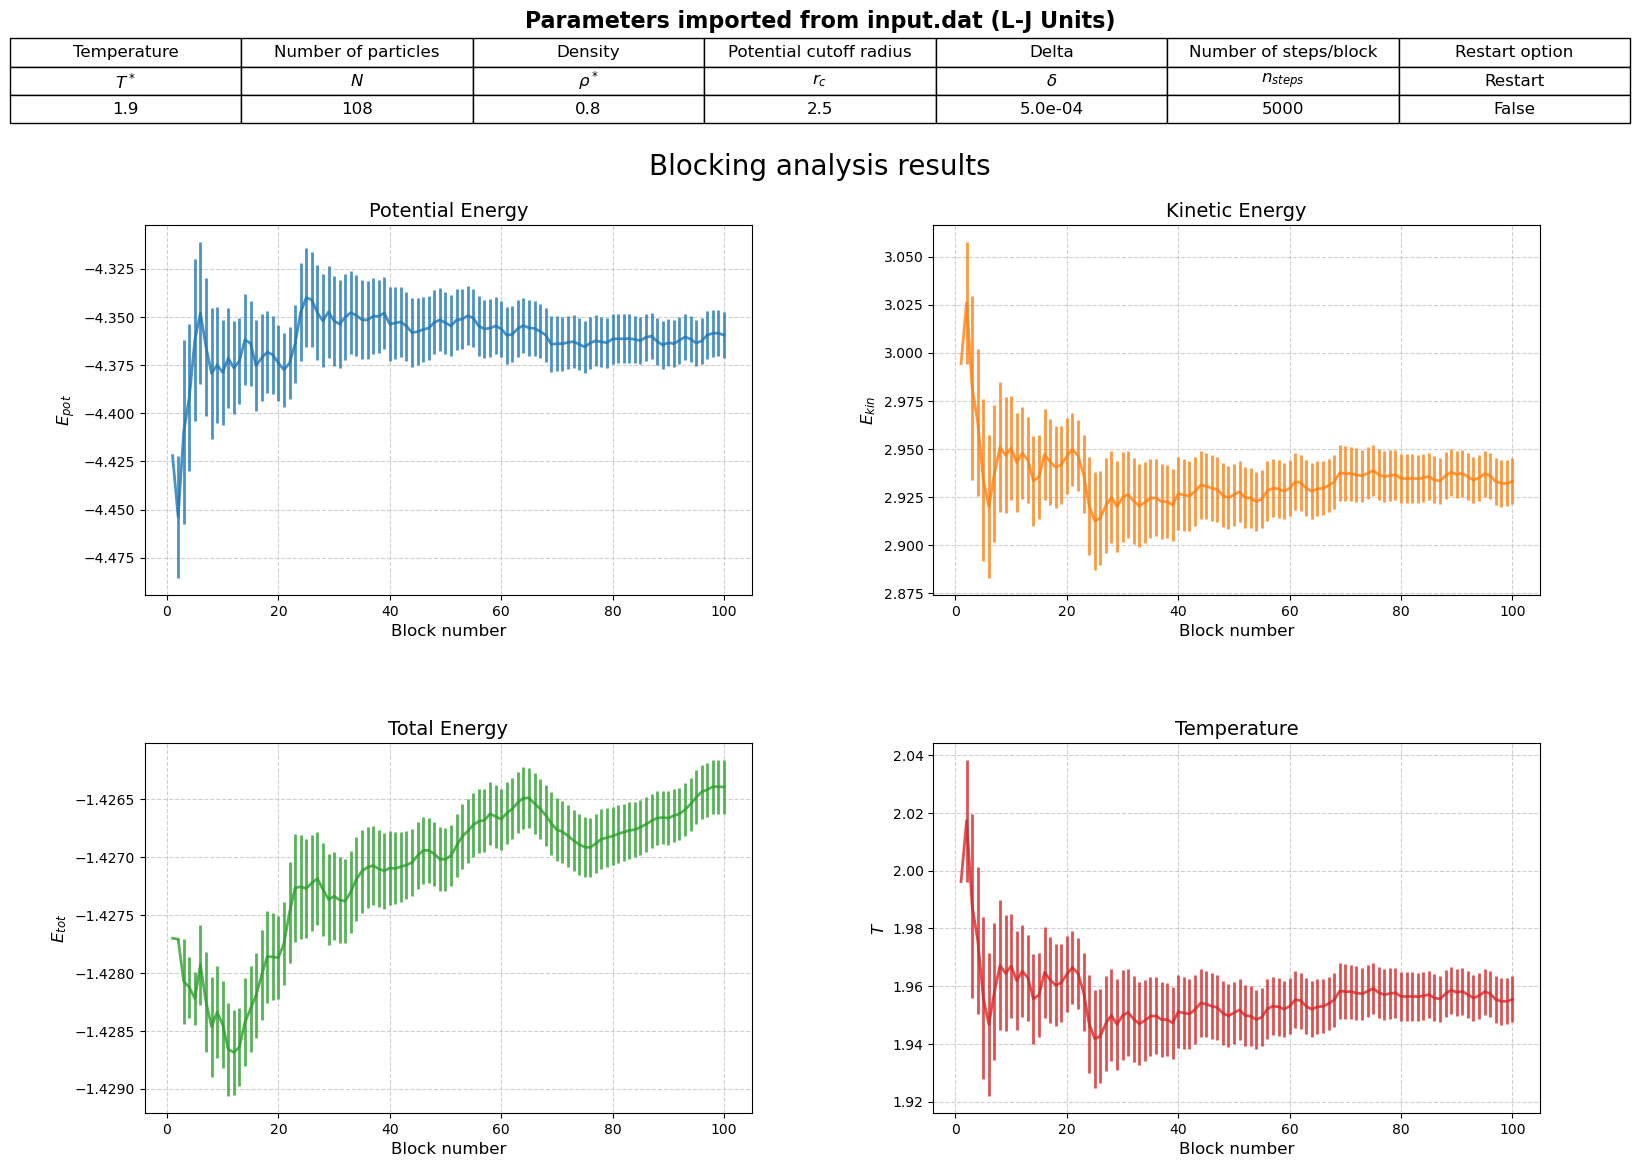

In [5]:
ave_res = np.loadtxt("./Results/blocked_stats_4.2.dat")
x = np.arange(1, len(ave_res) + 1)

title_labels = [r"Potential Energy", "Kinetic Energy", "Total Energy", "Temperature"]
labels = [r"$E_{pot}$", r"$E_{kin}$", r"$E_{tot}$", r"$T$"]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(18, 12))

ax_table = fig.add_axes([0.05, 0.93, 0.9, 0.08])
ax_table.axis("off")

ax_table.text(
    0.5, 1.0,
    "Parameters imported from input.dat (L-J Units)",
    fontsize=16,
    ha="center",
    va="bottom",
    fontweight='bold'
)

table_headers = ["Temperature", "Number of particles", "Density", "Potential cutoff radius", "Delta", "Number of steps/block", "Restart option"]

param_labels = [r'$T^*$', r'$N$', r'$\rho^*$', r'$r_c$', r'$\delta$', r'$n_{steps}$', 'Restart']

param_values = [
    f"{params['temp']:.3g}",
    int(params['npart']),
    f"{params['rho']:.3g}",
    f"{params['rcut']:.3g}",
    f"{params['delta']:.1e}",
    int(params['nstep']),
    str(params['restart'])
]

table_data = [table_headers, param_labels, param_values]

table = ax_table.table(
    cellText=table_data,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 1.7)

fig.subplots_adjust(top=0.85, hspace=0.4, wspace=0.3)

fig.suptitle("Blocking analysis results", fontsize=20, y=0.91)

for i, (label, title) in enumerate(zip(labels, title_labels)):
    ax = fig.add_subplot(2, 2, i + 1)
    
    y = ave_res[:, 2*i]
    yerr = ave_res[:, 2*i+1]
    
    ax.errorbar(x, y, yerr=yerr, linewidth=2, alpha=0.8, color=colors[i % len(colors)])
    
    ax.set_title(f"{title}", fontsize=14)
    ax.set_xlabel("Block number", fontsize=12)
    ax.set_ylabel(f"{label}", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Exercise 04.3 (Optional)

<span style="color:red">Include the calculation of the pressure, $P$, inside your Molecular Dynamics code</span>: istantaneous values, average values and uncertainties.

Remember that, via the **virial theorem**, the pressure in a Lennard-Jones system can be estimated by means of:

$$ P = \rho k_B T + \frac{1}{3V} \left\langle \sum_{i=1}^{N-1} \sum_{j\,(>i)}^N 48\epsilon \left[ \left(\frac{\sigma}{|\vec{r}_i -\vec{r}_j|}\right)^{12} - 
\frac{1}{2} \left(\frac{\sigma}{|\vec{r}_i -\vec{r}_j|}\right)^6 \right] \right\rangle $$

### Exercise 04.4

By means of your upgraded MD code, equilibrate and <span style="color:red">perform MD simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) and Krypton ($\sigma = 0.364$ nm, $\epsilon/k_B = 164$ K, $m=83.798$ amu) in the following conditions:
1. solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r_c = 2.2$)
2. liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)
3. gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r_c = 5.0$)

and show in pictures the obtained average values and uncertainties for the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the pressure $P$ and the temperature, $T$ ... in SI units!

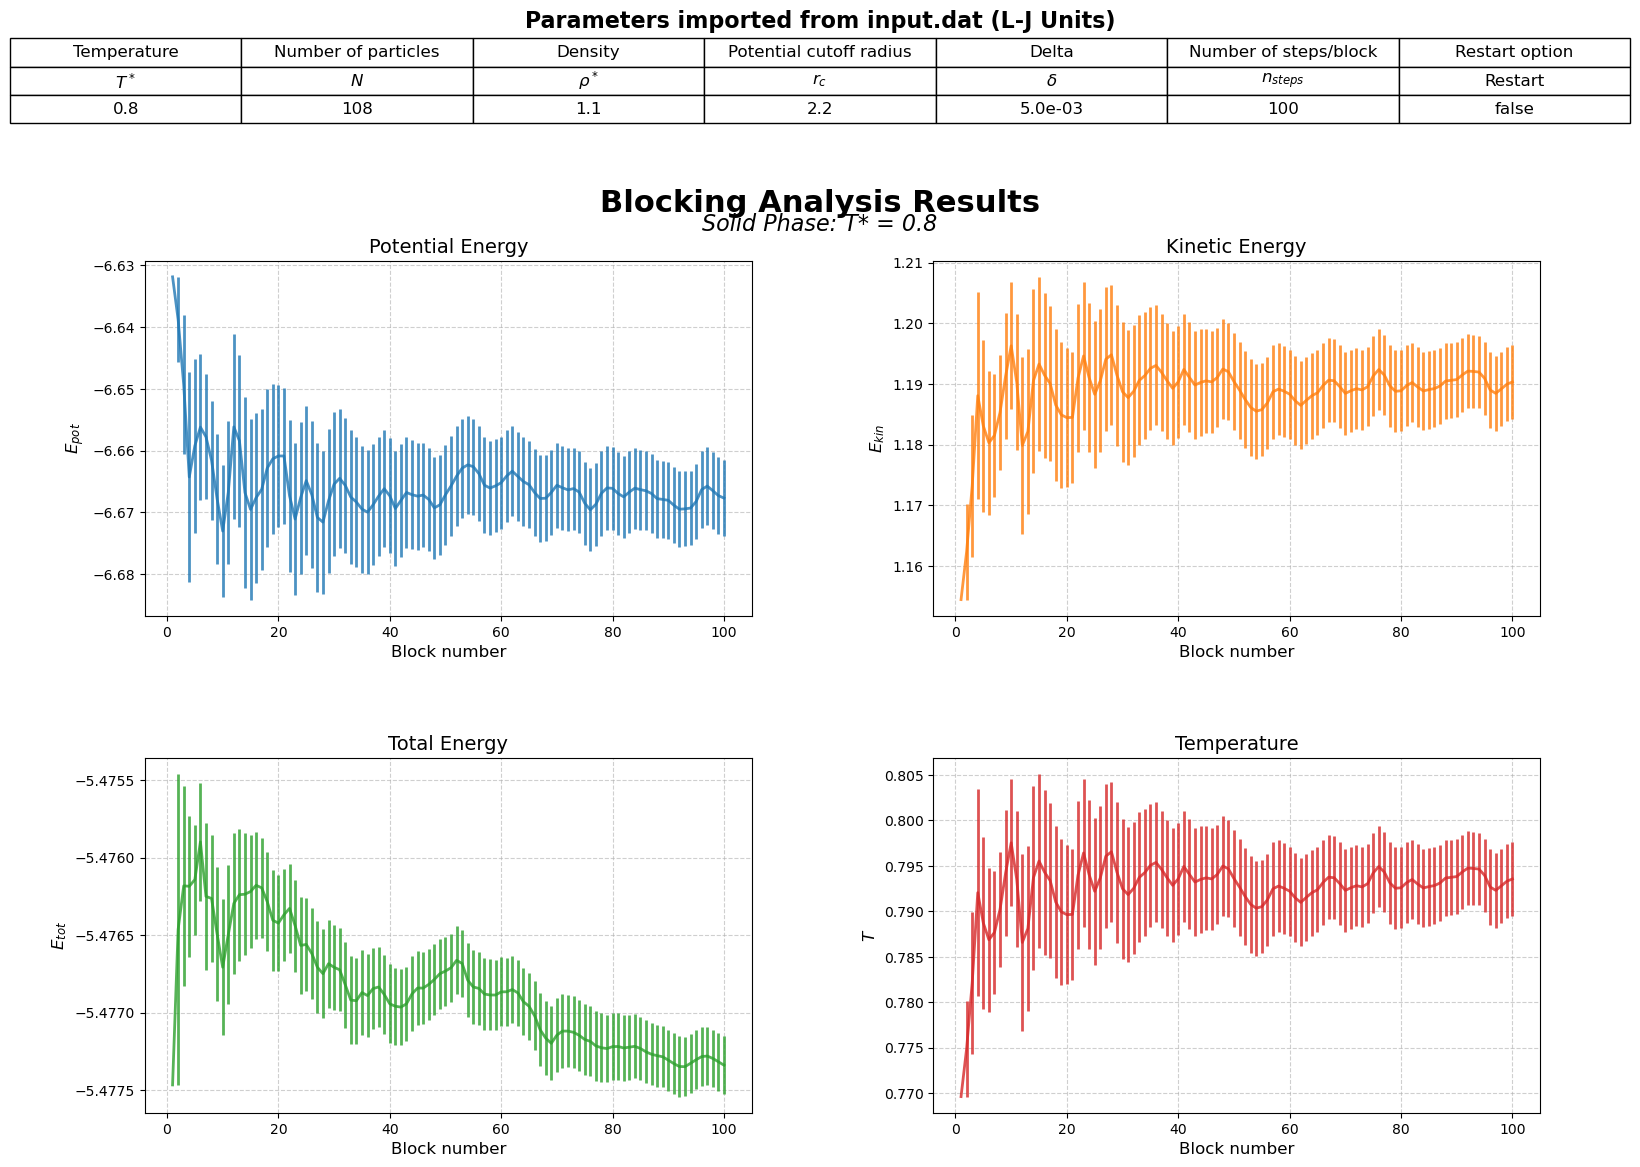

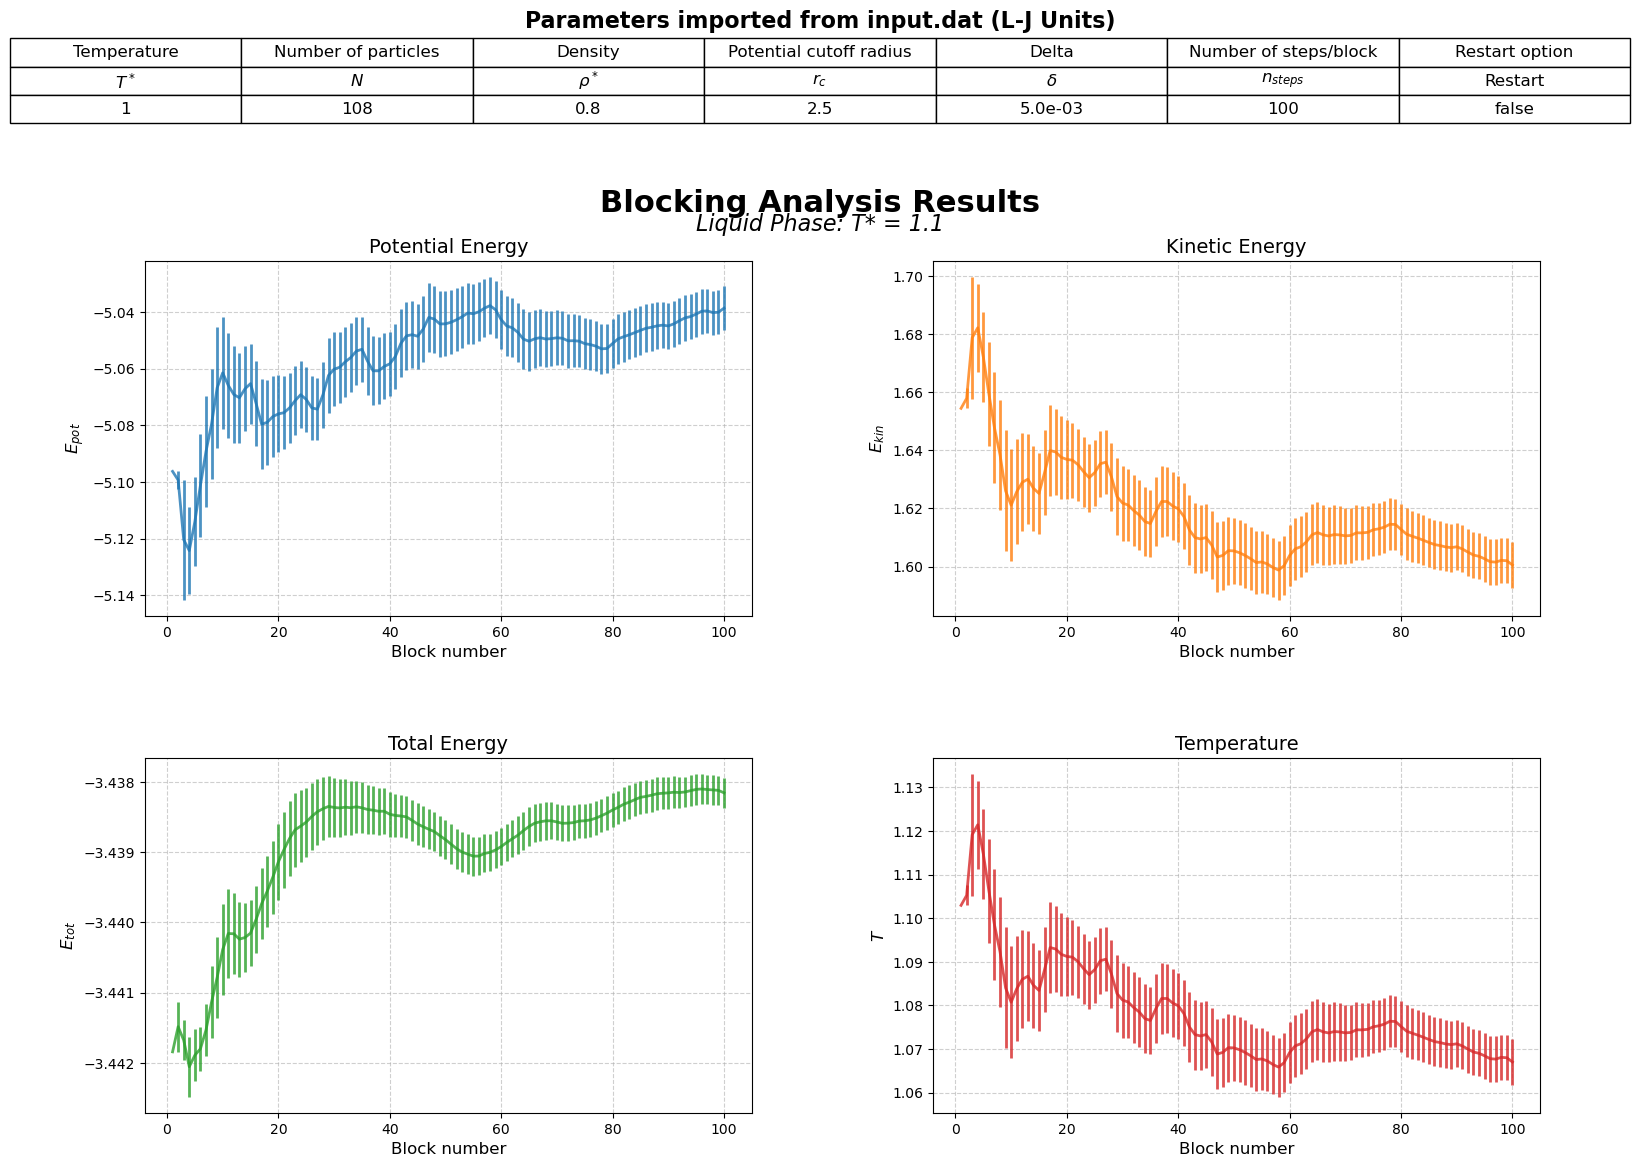

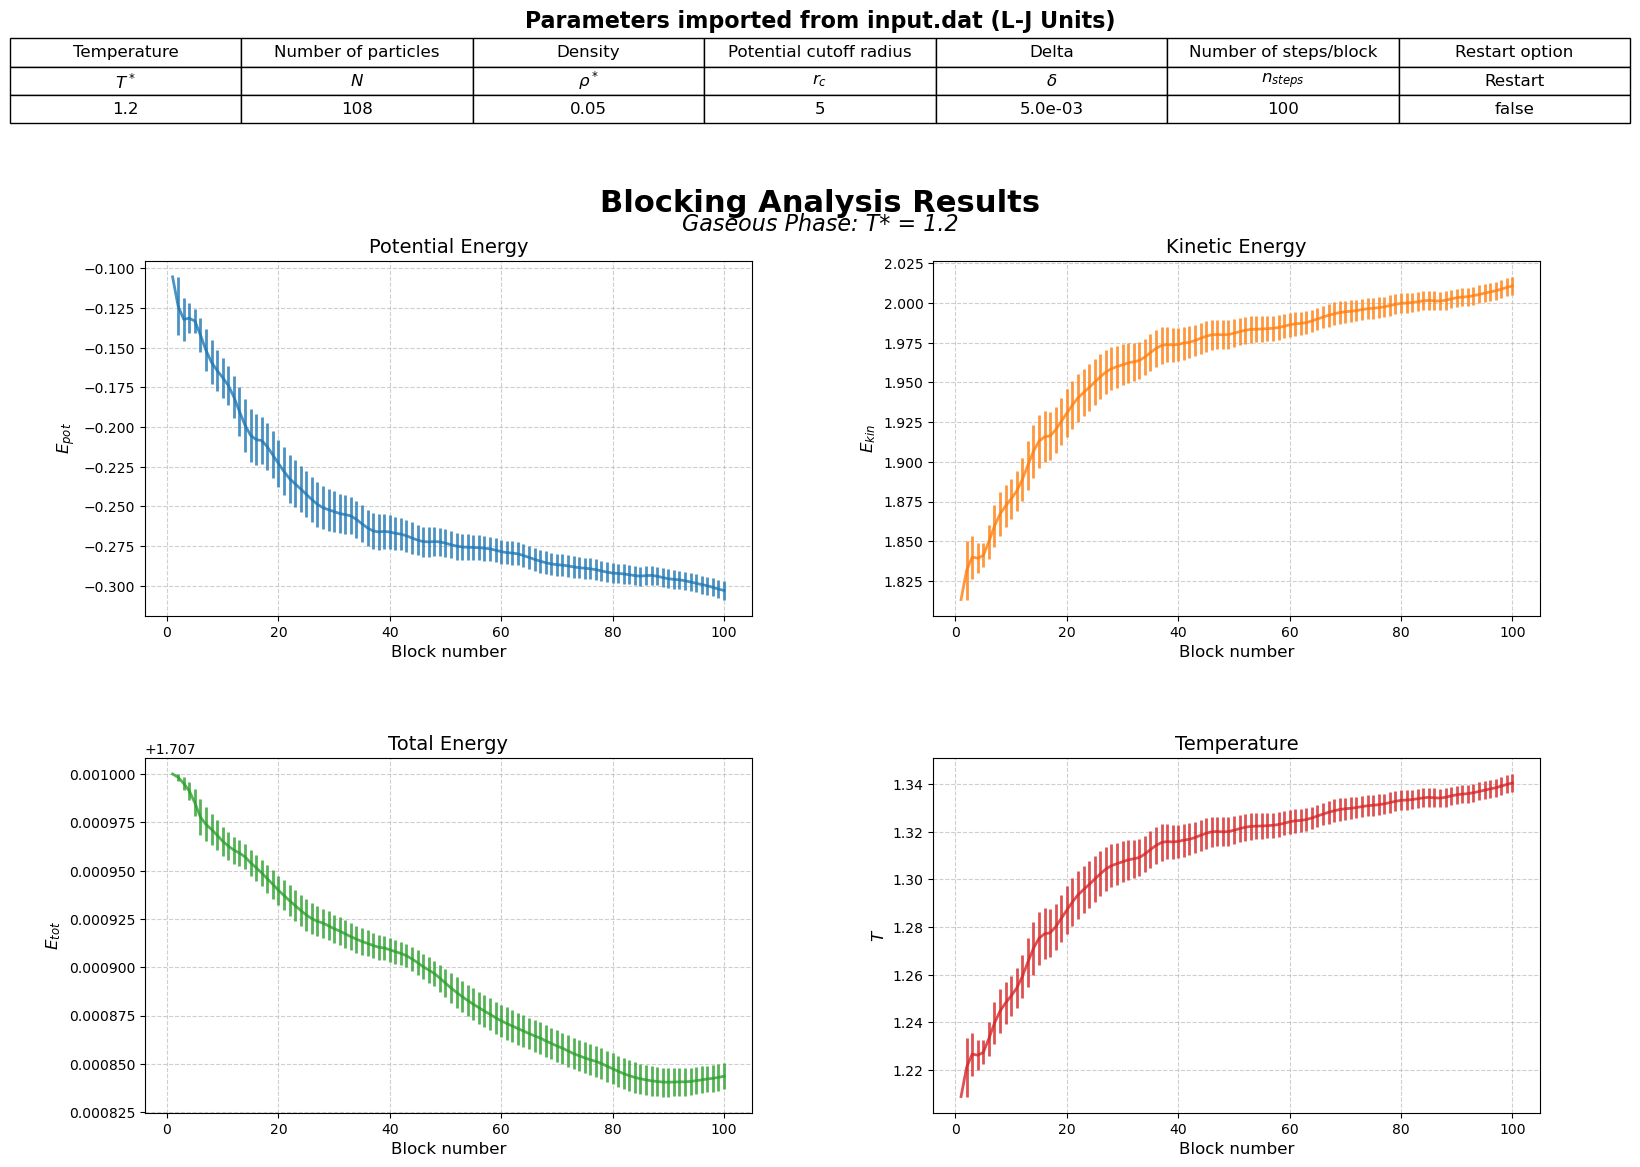

In [6]:
def plot_blocking_results(file_path, params, figure_subtitle):

    ave_res = np.loadtxt(file_path)
    x = np.arange(1, len(ave_res) + 1)

    title_labels = ["Potential Energy", "Kinetic Energy", "Total Energy", "Temperature"]
    labels = [r"$E_{pot}$", r"$E_{kin}$", r"$E_{tot}$", r"$T$"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig = plt.figure(figsize=(18, 12))

    ax_table = fig.add_axes([0.05, 0.93, 0.9, 0.08])
    ax_table.axis("off")
    ax_table.text(
        0.5, 1.0,
        "Parameters imported from input.dat (L-J Units)",
        fontsize=16,
        ha="center",
        va="bottom",
        fontweight='bold'
    )

    table_headers = ["Temperature", "Number of particles", "Density", "Potential cutoff radius", "Delta", "Number of steps/block", "Restart option"]
    param_labels = [r'$T^*$', r'$N$', r'$\rho^*$', r'$r_c$', r'$\delta$', r'$n_{steps}$', 'Restart']
    param_values = [
        f"{params['temp']:.3g}",
        int(params['npart']),
        f"{params['rho']:.3g}",
        f"{params['rcut']:.3g}",
        f"{params['delta']:.1e}",
        int(params['nstep']),
        str(params['restart'])
    ]
    table_data = [table_headers, param_labels, param_values]

    table = ax_table.table(
        cellText=table_data,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.0, 1.7)

    fig.subplots_adjust(top=0.82, hspace=0.4, wspace=0.3)

    fig.suptitle("Blocking Analysis Results", fontsize=22, y=0.88, fontweight='bold')
    fig.text(0.5, 0.845, figure_subtitle, ha='center', fontsize=16, fontstyle='italic')

    for i, (label, title) in enumerate(zip(labels, title_labels)):
        ax = fig.add_subplot(2, 2, i + 1)
        y = ave_res[:, 2*i]
        yerr = ave_res[:, 2*i+1]
        ax.errorbar(x, y, yerr=yerr, linewidth=2, alpha=0.8, color=colors[i % len(colors)])
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Block number", fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.show()

params1 = {'temp':0.8, 'npart':108, 'rho':1.1, 'rcut':2.2, 'delta':0.005, 'nstep':100, 'restart':'false'}
params2 = {'temp':1.0, 'npart':108, 'rho':0.8, 'rcut':2.5, 'delta':0.005, 'nstep':100, 'restart':'false'}
params3 = {'temp':1.2, 'npart':108, 'rho':0.05, 'rcut':5.0, 'delta':0.005, 'nstep':100, 'restart':'false'}

plot_blocking_results("./Results/blocked_stats_solid.dat", params1, "Solid Phase: T* = 0.8")
plot_blocking_results("./Results/blocked_stats_liquid.dat", params2, "Liquid Phase: T* = 1.1")
plot_blocking_results("./Results/blocked_stats_gas.dat", params3, "Gaseous Phase: T* = 1.2")